# Atencion en Transformers, explicada con triqui

Basado en Vaswani et al. (2017), *Attention Is All You Need*.

Este notebook entrena un mini-encoder tipo Transformer (el bloque de la mitad izquierda
de la Figura 1 del paper, sin decoder) sobre tableros de triqui (tic-tac-toe), y muestra
paso a paso: que es un embedding, como se calcula la atencion "a mano", como se arma un
bloque encoder completo, y que se ve dentro de la matriz de atencion una vez entrenado.

**Dos tareas, un solo modelo:**
1. **Casilla oculta**: dado un tablero con una casilla tapada (`[MASK]`), adivinar si
   ahi habia `X`, `O` o vacio (clasificacion de 3 clases).
2. **Gana X?**: dado el tablero completo, decidir si `X` tiene una linea ganadora
   (clasificacion binaria).

In [25]:
import time, collections
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

T0 = time.time()
SEED = 0
torch.manual_seed(SEED)   # misma semilla para torch y numpy: notebook reproducible de punta a punta
np.random.seed(SEED)
DEVICE = torch.device("cpu")

# Configuracion global de estilo para todas las figuras del notebook.
# Jerarquia tipografica: el titulo de cada panel resalta un poco (mas grande
# y en negrita) sobre las etiquetas de eje y los ticks, que se mantienen chicos
# para que quepan comodos en las figuras de 4 subplots (una por cabeza).
mpl.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white",
    "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
})

print("torch", torch.__version__, "| numpy", np.__version__, "| semilla", SEED)

torch 2.11.0+cpu | numpy 2.4.4 | semilla 0


## 1. Datos

Usamos tableros de triqui **reales y ya verificados**, no aleatorios: el dataset
UCI *Tic-Tac-Toe Endgame* (id 101), 958 tableros terminales. Si no hay conexion a
internet, se reconstruye el mismo conjunto por fuerza bruta (DFS sobre todas las
partidas legales con `X` moviendo primero) -- es el mismo dato, no una aproximacion.

Cada tablero son 9 casillas con valores en `{X, O, vacio}`, mas una etiqueta binaria
`gana_x` que se calcula revisando las 8 lineas posibles (3 filas, 3 columnas, 2
diagonales).

In [26]:
LINES = [(0,1,2),(3,4,5),(6,7,8),(0,3,6),(1,4,7),(2,5,8),(0,4,8),(2,4,6)]
LINE_NAMES = {
    (0,1,2): "fila de arriba", (3,4,5): "fila del medio", (6,7,8): "fila de abajo",
    (0,3,6): "columna izquierda", (1,4,7): "columna del medio", (2,5,8): "columna derecha",
    (0,4,8): "diagonal principal (arriba-izq a abajo-der)",
    (2,4,6): "diagonal secundaria (arriba-der a abajo-izq)",
}
X, O, B = 0, 1, 2                       # valores de casilla
# orden de columnas fijo (row-major) para que la casilla i siempre sea la misma
# posicion fisica del tablero, la use quien la use (UCI o la enumeracion local)
CANON_COLS = ["top-left-square", "top-middle-square", "top-right-square",
              "middle-left-square", "middle-middle-square", "middle-right-square",
              "bottom-left-square", "bottom-middle-square", "bottom-right-square"]

def winner(board):
    """Devuelve X u O si hay linea completa, None si no."""
    for i, j, k in LINES:
        if board[i] != B and board[i] == board[j] == board[k]:
            return board[i]
    return None

def enumerate_terminal_boards():
    """DFS sobre partidas legales; junta las posiciones terminales (fallback sin red)."""
    out = set()
    def dfs(b):
        empties = [i for i, v in enumerate(b) if v == B]
        if winner(b) is not None or not empties:
            out.add(b); return
        player = X if b.count(X) == b.count(O) else O
        for i in empties:
            nb = list(b); nb[i] = player; dfs(tuple(nb))
    dfs((B,) * 9)
    return out

try:
    # intento 1: dataset real via red (UCI repo id=101)
    from ucimlrepo import fetch_ucirepo
    ds = fetch_ucirepo(id=101)
    Xdf, ydf = ds.data.features, ds.data.targets
    if list(Xdf.columns) != CANON_COLS:
        Xdf = Xdf[CANON_COLS]                                  # reordena a row-major si vino en otro orden
    _map = {"x": X, "o": O, "b": B}                             # texto UCI -> enteros internos
    boards = np.array([[_map[v] for v in row] for row in Xdf.values], dtype=np.int64)
    cls_label = (ydf.iloc[:, 0].values == "positive").astype(np.int64)
    FUENTE = "ucimlrepo (archive.ics.uci.edu, id=101)"
except Exception as e:
    # intento 2 (sin red o sin el paquete instalado): reconstruimos el mismo
    # conjunto de 958 tableros por fuerza bruta, no es una aproximacion
    print("Descarga fallida (%s); se usa enumeracion local (mismo resultado)." % type(e).__name__)
    boards_enum = sorted(enumerate_terminal_boards())
    boards = np.array(boards_enum, dtype=np.int64)
    cls_label = np.array([1 if winner(b) == X else 0 for b in boards_enum], dtype=np.int64)
    FUENTE = "fallback: enumeracion local de tableros terminales"

assert boards.shape[1] == 9 and len(boards) == len(cls_label)
print("Fuente:", FUENTE)
print("Tableros:", boards.shape[0], "| gana X:", cls_label.sum(), "| no gana X:", (cls_label == 0).sum())

Fuente: ucimlrepo (archive.ics.uci.edu, id=101)
Tableros: 958 | gana X: 626 | no gana X: 332


### Numeracion de las casillas, y ejemplos

Para poder leer resultados como "linea ganadora: (1, 4, 7)" en las secciones
siguientes, esta es la numeracion **fija** de las 9 casillas que usa todo el
notebook (por filas, de izquierda a derecha):

```
0 1 2
3 4 5
6 7 8
```

Con esa numeracion, `LINES` (definida arriba) son las 3 filas, 3 columnas y 2
diagonales -- por ejemplo, `(1,4,7)` es la columna del medio. Abajo se
imprime esa tabla de numeracion junto con el nombre de cada linea, y despues
tres tableros al azar del dataset, como grilla 3x3, con su etiqueta real de
"gana X?".

In [27]:
print("numeracion de las 9 casillas (fija, se usa en todo el notebook):")
for r in range(3):
    print("  " + " ".join(str(3 * r + c) for c in range(3)))
print("\nlas 8 lineas posibles con esta numeracion:")
for line in LINES:
    print("  %s = %s" % (line, LINE_NAMES[line]))

CHAR = {X: "X", O: "O", B: "."}

def print_board(b, label=None, mask_pos=None):
    """Imprime b (lista de 9 valores) como grilla 3x3; mask_pos se muestra como '?'."""
    if label:
        print(label)
    for r in range(3):
        row = []
        for c in range(3):
            p = 3 * r + c                                # indice lineal 0..8, igual que en LINES
            row.append("?" if p == mask_pos else CHAR[b[p]])
        print("  " + " ".join(row))
    print()

rng_show = np.random.default_rng(SEED)
idx_ejemplos = rng_show.choice(len(boards), size=3, replace=False)
print()
for i in idx_ejemplos:
    print_board(boards[i], label="tablero %d  (gana X: %s)" % (i, bool(cls_label[i])))

EJ_IDX = int(idx_ejemplos[0])
print("(usaremos el tablero %d de arriba como ejemplo en las secciones 2 y 3)" % EJ_IDX)

numeracion de las 9 casillas (fija, se usa en todo el notebook):
  0 1 2
  3 4 5
  6 7 8

las 8 lineas posibles con esta numeracion:
  (0, 1, 2) = fila de arriba
  (3, 4, 5) = fila del medio
  (6, 7, 8) = fila de abajo
  (0, 3, 6) = columna izquierda
  (1, 4, 7) = columna del medio
  (2, 5, 8) = columna derecha
  (0, 4, 8) = diagonal principal (arriba-izq a abajo-der)
  (2, 4, 6) = diagonal secundaria (arriba-der a abajo-izq)

tablero 609  (gana X: True)
  . . O
  X X X
  O X O

tablero 489  (gana X: True)
  . X X
  O X .
  O X O

tablero 813  (gana X: False)
  O O O
  X X O
  . X X

(usaremos el tablero 609 de arriba como ejemplo en las secciones 2 y 3)


## 2. Embeddings

Una red no entiende los simbolos `X`, `O`, `[MASK]` -- necesita numeros. Un
**embedding** es una tabla aprendible que le asigna a cada simbolo un vector en
$\mathbb{R}^d$. Nuestro vocabulario tiene 5 simbolos: `X`, `O`, `vacio`, `[MASK]`
(la casilla que hay que adivinar) y `[CLS]` (un token extra, sin contenido de
tablero, que se agrega al final de la secuencia y cuyo vector final se usa para
la tarea "gana X?" -- es el mismo truco que usa BERT).

**Por que hace falta ademas una posicion?** La atencion (seccion 3) compara
vectores entre si sin importar en que orden vienen -- es **equivariante a
permutaciones**. Sin una senal de posicion, el modelo no podria distinguir una
`X` en la esquina de una `X` en el centro: verian el mismo vector. Por eso se
suma un segundo embedding, de **posicion** (una tabla de 10 vectores, una por
casilla del 0 al 8 mas el token `[CLS]`), al embedding de contenido:

$$t_i = E_{\text{token}}[\text{simbolo}_i] + E_{\text{pos}}[i]$$

Abajo se ve esto en tres graficos: la tabla de simbolos, la tabla de posiciones,
y el resultado de sumarlas para un tablero concreto -- para confirmar que **dos
casillas con el mismo simbolo `X` terminan en vectores distintos**, porque estan
en posiciones distintas.

tablero 609 (el mismo mostrado en la Seccion 1):
  . . O
  X X X
  O X O



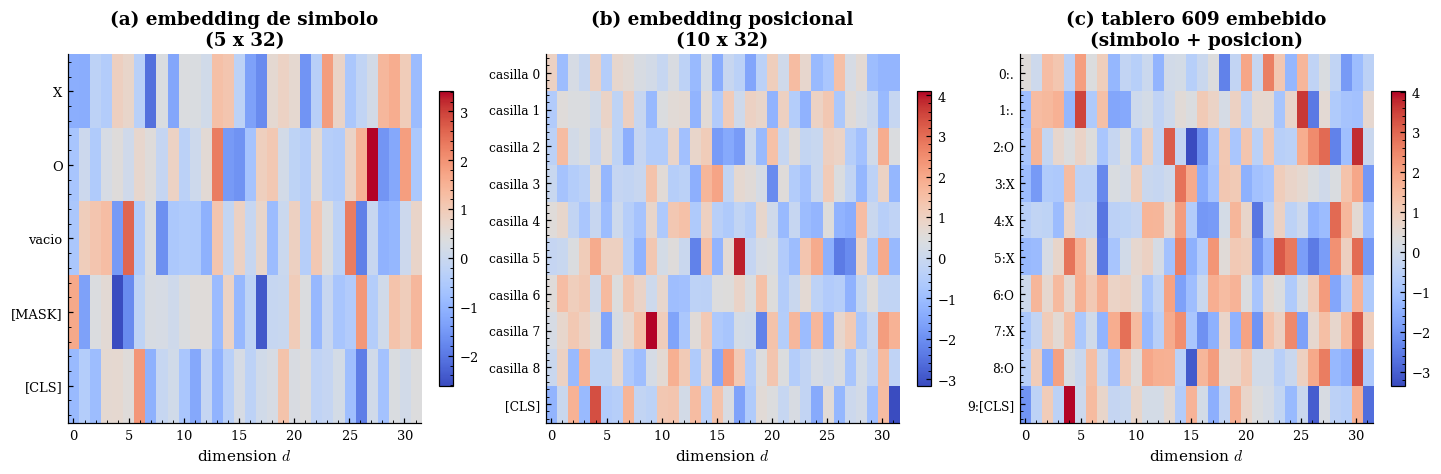

tablero 609: ..OXXXOXO
las casillas 3 y 4 son ambas 'X' en (a)-(b) combinadas, pero en (c) son vectores distintos:
  ||embebido[3] - embebido[4]|| = 6.754677772521973


In [28]:
D_MODEL = 32
VOCAB = ["X", "O", "vacio", "[MASK]", "[CLS]"]
ID_X, ID_O, ID_B, ID_MASK, ID_CLS = 0, 1, 2, 3, 4
N_POS = 10   # 9 casillas + [CLS]

demo_tok_emb = nn.Embedding(len(VOCAB), D_MODEL)
demo_pos_emb = nn.Embedding(N_POS, D_MODEL)

# reutilizamos el mismo tablero ya mostrado en la Seccion 1 (EJ_IDX), con su token [CLS] al final
ej_board = boards[EJ_IDX]
print("tablero %d (el mismo mostrado en la Seccion 1):" % EJ_IDX)
print_board(ej_board)

ej_token_ids = torch.tensor([*ej_board, ID_CLS])              # (10,)
ej_pos_ids = torch.arange(N_POS)                               # (10,)
with torch.no_grad():
    ej_embedded = demo_tok_emb(ej_token_ids) + demo_pos_emb(ej_pos_ids)   # (10, D_MODEL)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True,
                          gridspec_kw={"width_ratios": [1, 1, 1]})

im0 = axes[0].imshow(demo_tok_emb.weight.detach().numpy(), cmap="coolwarm", aspect="auto")
axes[0].set_yticks(range(5)); axes[0].set_yticklabels(VOCAB)
axes[0].set_xlabel("dimension $d$"); axes[0].set_title("(a) embedding de simbolo\n(5 x %d)" % D_MODEL)
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(demo_pos_emb.weight.detach().numpy(), cmap="coolwarm", aspect="auto")
pos_labels = ["casilla %d" % i for i in range(9)] + ["[CLS]"]
axes[1].set_yticks(range(10)); axes[1].set_yticklabels(pos_labels, fontsize=8)
axes[1].set_xlabel("dimension $d$"); axes[1].set_title("(b) embedding posicional\n(10 x %d)" % D_MODEL)
fig.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(ej_embedded.numpy(), cmap="coolwarm", aspect="auto")
row_labels = ["%d:%s" % (i, CHAR[v]) for i, v in enumerate(ej_board)] + ["9:[CLS]"]
axes[2].set_yticks(range(10)); axes[2].set_yticklabels(row_labels, fontsize=8)
axes[2].set_xlabel("dimension $d$"); axes[2].set_title("(c) tablero %d embebido\n(simbolo + posicion)" % EJ_IDX)
fig.colorbar(im2, ax=axes[2], shrink=0.8)
plt.show()

# dos casillas con el mismo simbolo (siempre existen: 9 casillas, 3 simbolos posibles)
# para confirmar que su vector embebido difiere -- solo la posicion los distingue.
# se prefiere un par de X o de O (mas ilustrativo que un par de vacio) si hay.
grupos_por_simbolo = {}
for p, v in enumerate(ej_board):
    grupos_por_simbolo.setdefault(v, []).append(p)
p_a, p_b = next(grupos_por_simbolo[sym][:2] for sym in (X, O, B)
                if len(grupos_por_simbolo.get(sym, [])) >= 2)
print("tablero %d:" % EJ_IDX, "".join(CHAR[v] for v in ej_board))
print("las casillas %d y %d son ambas '%s' en (a)-(b) combinadas, pero en (c) son vectores distintos:"
      % (p_a, p_b, CHAR[ej_board[p_a]]))
print("  ||embebido[%d] - embebido[%d]|| =" % (p_a, p_b), float((ej_embedded[p_a] - ej_embedded[p_b]).norm()))

**Figura 1.** Embeddings del tablero de ejemplo. (a) tabla de embedding
de simbolo, una fila por simbolo del vocabulario; (b) tabla de embedding
posicional, una fila por posicion (9 casillas + `[CLS]`); (c) el tablero de
ejemplo ya embebido, suma de (a) y (b) fila a fila. El color codifica el
valor de cada componente del vector (rojo = positivo, azul = negativo).

## 3. Atencion de producto punto escalado, "a mano"

Esta es la Figura 2 (izquierda) del paper. La formula completa:

$$Q = XW_Q,\quad K = XW_K,\quad V = XW_V,\qquad
\text{Attention}(Q,K,V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

La idea, en una frase: **cada casilla genera una "pregunta" ($Q$)**, la compara
(producto punto) contra la **"etiqueta" ($K$) de todas las demas casillas**, y
usa esos puntajes de compatibilidad -- normalizados con softmax para que sumen 1
-- como pesos para promediar el **"contenido" ($V$)** de las demas. Una fila de
la matriz de atencion resultante es literalmente la pregunta de esa casilla
dirigida a todas las otras.

El $1/\sqrt{d_k}$ evita que los productos punto crezcan con la dimension y
saturen el softmax (lo que apagaria el gradiente). Abajo se calcula esto paso a
paso, en el mismo tablero embebido de la seccion anterior, con $W_Q, W_K, W_V$
elegidos al azar (todavia no hay entrenamiento -- es solo para ver la mecanica).

Q, K, V: torch.Size([10, 32]) torch.Size([10, 32]) torch.Size([10, 32])
scores = Q K^T / sqrt(d_k): torch.Size([10, 10])
A = softmax(scores), cada fila suma: [1.0000001192092896, 1.0, 1.0] ...
output = A @ V: torch.Size([10, 32])


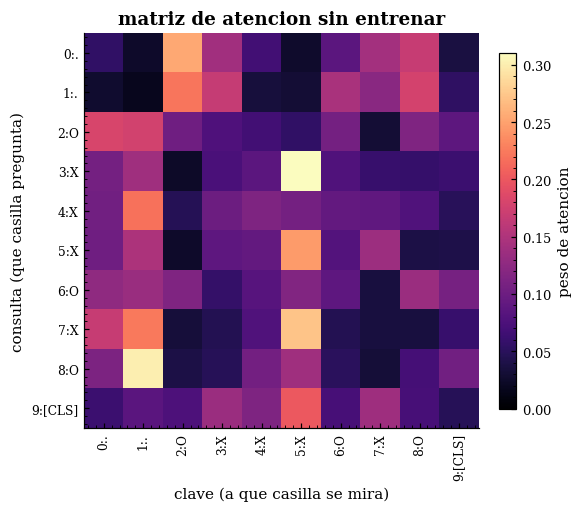

In [29]:
d_k = D_MODEL  # una sola "cabeza" por ahora, para ver la formula desnuda
Wq = nn.Linear(D_MODEL, d_k, bias=False)
Wk = nn.Linear(D_MODEL, d_k, bias=False)
Wv = nn.Linear(D_MODEL, d_k, bias=False)

with torch.no_grad():
    Q = Wq(ej_embedded)                      # (10, d_k)  -- "la pregunta de cada casilla"
    K = Wk(ej_embedded)                      # (10, d_k)  -- "la etiqueta de cada casilla"
    V = Wv(ej_embedded)                      # (10, d_k)  -- "el contenido de cada casilla"

    scores = Q @ K.T / (d_k ** 0.5)          # (10, 10)   -- QK^T / sqrt(d_k)
    A = torch.softmax(scores, dim=-1)        # (10, 10)   -- cada fila suma 1
    output = A @ V                            # (10, d_k)  -- promedio ponderado de V

print("Q, K, V:", Q.shape, K.shape, V.shape)
print("scores = Q K^T / sqrt(d_k):", scores.shape)
print("A = softmax(scores), cada fila suma:", A.sum(-1)[:3].tolist(), "...")
print("output = A @ V:", output.shape)

fig, ax = plt.subplots(figsize=(5.2, 4.6), constrained_layout=True)
im = ax.imshow(A.numpy(), cmap="magma", vmin=0)
ax.set_xticks(range(10)); ax.set_xticklabels(row_labels, rotation=90, fontsize=8)
ax.set_yticks(range(10)); ax.set_yticklabels(row_labels, fontsize=8)
ax.set_xlabel("clave (a que casilla se mira)"); ax.set_ylabel("consulta (que casilla pregunta)")
ax.set_title("matriz de atencion sin entrenar")
fig.colorbar(im, ax=ax, shrink=0.85, label="peso de atencion")
plt.show()

**Figura 2.** Matriz de atencion $A = \mathrm{softmax}(QK^\top/\sqrt{d_k})$
calculada a mano, sin entrenar, sobre el tablero de ejemplo. Cada fila es la
consulta de una casilla; cada columna, cuanto peso recibe de esa consulta la
casilla correspondiente. Los colores mas claros indican mayor peso; cada fila
suma 1 (es una distribucion de probabilidad).

**Esto no es una capa densa comun.** En una capa tradicional $y = f(Wx + b)$,
$W$ es fija una vez entrenada: el mismo peso se aplica sin importar el input.
Aca, $W_Q, W_K, W_V, W_O$ **si** son parametros aprendidos igual que cualquier
`nn.Linear` -- pero la matriz $A$ (los pesos de atencion) **no es un parametro**:
es una **salida intermedia, recalculada en cada pasada** a partir del input
concreto. Dos tableros distintos producen dos matrices $A$ distintas con los
*mismos* $W_Q, W_K, W_V$. Eso es lo que hace que la atencion sea "dinamica" y,
de paso, interpretable: se puede mirar la $A$ de un ejemplo especifico.

## 4. Modelo completo: mini Transformer encoder

Ahora s el bloque encoder real (mitad izquierda de la Figura 1 del paper, sin
decoder), con **multiples cabezas** de atencion en paralelo (`nn.MultiheadAttention`,
para poder comparar despues que aprendio cada cabeza) y, despues de la atencion,
**Add & Norm -> Feed Forward -> Add & Norm**:

$$x \leftarrow \mathrm{LayerNorm}(x + \mathrm{MultiHead}(x))
\qquad
x \leftarrow \mathrm{LayerNorm}(x + \mathrm{FFN}(x))$$

Usamos **2 bloques** apilados, `D_MODEL=32`, **4 cabezas**. El modelo tiene dos
"cabezas de salida" (no confundir con las cabezas de atencion):

- **Cabeza A** (casilla oculta): una capa lineal sobre el vector final **en la
  posicion enmascarada** -> 3 clases (`X`/`O`/vacio).
- **Cabeza B** (gana X?): una capa lineal sobre el vector final **del token
  `[CLS]`** -> 1 logit -> sigmoide. *(Se eligio `[CLS]` en vez de promediar las
  9 casillas porque as el modelo decide, con sus propios pesos de atencion,
  cuanto pesar cada casilla para esa pregunta -- un promedio fijo no permite
  ver eso en la Seccion 6.)*

In [30]:
class EncoderBlock(nn.Module):
    """Un bloque encoder: Multi-Head Attention -> Add&Norm -> Feed Forward -> Add&Norm."""

    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.mha = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))  # d_ff = 4*d_model
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # average_attn_weights=False: sin esto, pytorch promedia las cabezas y
        # perdemos justo lo que queremos graficar en la Seccion 6 (cada cabeza
        # por separado). attn_w sale con forma (batch, n_heads, 10, 10).
        attn_out, attn_w = self.mha(x, x, x, need_weights=True, average_attn_weights=False)
        x = self.norm1(x + attn_out)     # Add & Norm (post-atencion): residual + normalizacion
        x = self.norm2(x + self.ffn(x))  # Add & Norm (post-FFN)
        return x, attn_w


class TicTacToeEncoder(nn.Module):
    """Embeddings + n_layers bloques encoder + dos cabezas de salida (casilla y clase)."""

    def __init__(self, d_model=D_MODEL, n_heads=4, n_layers=2, d_ff=128, n_pos=N_POS):
        super().__init__()
        self.tok_emb = nn.Embedding(len(VOCAB), d_model)
        self.pos_emb = nn.Embedding(n_pos, d_model)
        self.blocks = nn.ModuleList(EncoderBlock(d_model, n_heads, d_ff) for _ in range(n_layers))
        self.head_cell = nn.Linear(d_model, 3)   # X / O / vacio
        self.head_cls = nn.Linear(d_model, 1)    # gana X (logit, sin sigmoide todavia)

    def forward(self, token_ids):
        # token_ids: (batch, 10) con las 9 casillas (o [MASK]) + [CLS] en la posicion 9
        B_, L = token_ids.shape
        pos_ids = torch.arange(L, device=token_ids.device).unsqueeze(0).expand(B_, L)  # (batch, 10): 0..9 repetido
        x = self.tok_emb(token_ids) + self.pos_emb(pos_ids)   # embedding de simbolo + de posicion
        attn_maps = []
        for block in self.blocks:
            x, attn_w = block(x)
            attn_maps.append(attn_w)   # una entrada por capa, para poder comparar capa 1 vs capa 2 despues
        return x, attn_maps   # x: (batch, 10, d_model); attn_maps: lista de (batch, n_heads, 10, 10)


torch.manual_seed(SEED)
model = TicTacToeEncoder()
n_params = sum(p.numel() for p in model.parameters())
print(model)
print("\nparametros entrenables:", n_params)

TicTacToeEncoder(
  (tok_emb): Embedding(5, 32)
  (pos_emb): Embedding(10, 32)
  (blocks): ModuleList(
    (0-1): 2 x EncoderBlock(
      (mha): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
      )
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=32, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=32, bias=True)
      )
      (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    )
  )
  (head_cell): Linear(in_features=32, out_features=3, bias=True)
  (head_cls): Linear(in_features=32, out_features=1, bias=True)
)

parametros entrenables: 26020


**Importante: la matriz de atencion no es la salida del modelo.** Es un
resultado intermedio dentro de cada bloque. Para llegar a una prediccion, el
vector todavia pasa por Add & Norm, la Feed Forward, otro Add & Norm, un
segundo bloque completo, y finalmente la capa lineal de salida. El heatmap de
atencion que vamos a ver en la Seccion 6 explica **como se movio la
informacion**, no reemplaza a la prediccion final -- por eso, debajo de cada
heatmap, siempre se imprime tambien la prediccion real con su probabilidad.

## 5. Entrenamiento

**Decision de diseno:** se entrena **un solo modelo, multi-tarea**, en vez de
dos modelos separados. Las dos tareas comparten el mismo encoder (mismos
embeddings, mismos bloques de atencion) y en cada paso se suman las dos
perdidas, `perdida = perdida_A + perdida_B`, antes de un unico `backward()`.
Se eligio asi porque ambas tareas son sobre el mismo objeto (un tablero de
triqui) y comparten la misma nocion util de "geometria del tablero" -- tiene
sentido que el modelo aprenda una sola representacion que sirva para las dos.

Cada tablero entra dos veces por epoca: una version con una casilla al azar
tapada con `[MASK]` (para la Cabeza A, con la casilla verdadera como etiqueta)
y una version completa sin tapar (para la Cabeza B, con la etiqueta `gana_x`).
La casilla que se tapa se vuelve a sortear en cada epoca (augmentacion simple).

In [31]:
from sklearn.model_selection import train_test_split

idx_all = np.arange(len(boards))
# stratify=cls_label: mismo porcentaje de tableros "gana X" en train y val
idx_tr, idx_va = train_test_split(idx_all, test_size=0.2, random_state=SEED, stratify=cls_label)
print("train=%d  val=%d" % (len(idx_tr), len(idx_va)))

def build_full(idx):
    """(n, 10): tablero completo + [CLS] al final."""
    n = len(idx)
    cls_col = np.full((n, 1), ID_CLS, dtype=np.int64)
    return torch.from_numpy(np.concatenate([boards[idx], cls_col], axis=1))

def build_masked(idx, mask_pos):
    """(n, 10) con una casilla tapada por muestra, + [CLS]; y el valor real tapado."""
    n = len(idx)
    cells = boards[idx].copy()
    target = cells[np.arange(n), mask_pos].copy()
    cells[np.arange(n), mask_pos] = ID_MASK
    cls_col = np.full((n, 1), ID_CLS, dtype=np.int64)
    ids = torch.from_numpy(np.concatenate([cells, cls_col], axis=1))
    return ids, torch.from_numpy(target)

rng_train = np.random.default_rng(SEED)
rng_val = np.random.default_rng(SEED + 1)          # mascara de validacion FIJA (no se resortea)
mask_pos_va = rng_val.integers(0, 9, size=len(idx_va))

ids_full_tr_static = build_full(idx_tr)             # tablero completo no cambia entre epocas
tgt_cls_tr = torch.from_numpy(cls_label[idx_tr]).float()
ids_full_va = build_full(idx_va)
tgt_cls_va = torch.from_numpy(cls_label[idx_va]).float()
ids_masked_va, tgt_cell_va = build_masked(idx_va, mask_pos_va)

opt = torch.optim.Adam(model.parameters(), lr=3e-3)
N_EPOCHS = 150
hist = {"total": [], "A": [], "B": []}

t_train0 = time.time()
for epoch in range(N_EPOCHS):
    model.train()
    mask_pos_tr = rng_train.integers(0, 9, size=len(idx_tr))
    ids_masked_tr, tgt_cell_tr = build_masked(idx_tr, mask_pos_tr)

    x_A, _ = model(ids_masked_tr)
    # x_A tiene forma (n_tr, 10, d_model); para cada tablero i necesitamos SU PROPIA
    # posicion tapada mask_pos_tr[i] (no es la misma columna para todos), por eso se
    # indexa con dos arreglos en paralelo: (fila i, columna mask_pos_tr[i]) para cada i
    logits_cell = model.head_cell(x_A[torch.arange(len(idx_tr)), torch.from_numpy(mask_pos_tr)])
    loss_A = F.cross_entropy(logits_cell, tgt_cell_tr)

    x_B, _ = model(ids_full_tr_static)
    logit_cls = model.head_cls(x_B[:, 9, :]).squeeze(-1)   # posicion 9 = [CLS] para todos los tableros
    loss_B = F.binary_cross_entropy_with_logits(logit_cls, tgt_cls_tr)

    loss = loss_A + loss_B   # multi-tarea: un unico backward optimiza ambas a la vez
    opt.zero_grad(); loss.backward(); opt.step()
    hist["total"].append(loss.item()); hist["A"].append(loss_A.item()); hist["B"].append(loss_B.item())

    if (epoch + 1) % 30 == 0:
        print("epoca %3d | perdida total %.4f | casilla %.4f | gana_x %.4f"
              % (epoch + 1, loss.item(), loss_A.item(), loss_B.item()))

print("\nentrenamiento: %.1f s" % (time.time() - t_train0))

model.eval()   # apaga dropout/etc. (aca no hay, pero es el habito correcto)
with torch.no_grad():
    x_A_va, _ = model(ids_masked_va)
    pred_cell_va = model.head_cell(x_A_va[torch.arange(len(idx_va)), torch.from_numpy(mask_pos_va)]).argmax(-1)
    acc_A = (pred_cell_va == tgt_cell_va).float().mean().item()

    x_B_va, _ = model(ids_full_va)
    pred_cls_va = (torch.sigmoid(model.head_cls(x_B_va[:, 9, :]).squeeze(-1)) > 0.5).long()
    acc_B = (pred_cls_va == tgt_cls_va.long()).float().mean().item()

print("exactitud validacion -- casilla oculta: %.3f | gana X?: %.3f" % (acc_A, acc_B))

train=766  val=192
epoca  30 | perdida total 0.7994 | casilla 0.6033 | gana_x 0.1961
epoca  60 | perdida total 0.4935 | casilla 0.4188 | gana_x 0.0746
epoca  90 | perdida total 0.3757 | casilla 0.3323 | gana_x 0.0434
epoca 120 | perdida total 0.3399 | casilla 0.3170 | gana_x 0.0229
epoca 150 | perdida total 0.3442 | casilla 0.3212 | gana_x 0.0230

entrenamiento: 7.7 s
exactitud validacion -- casilla oculta: 0.818 | gana X?: 0.979


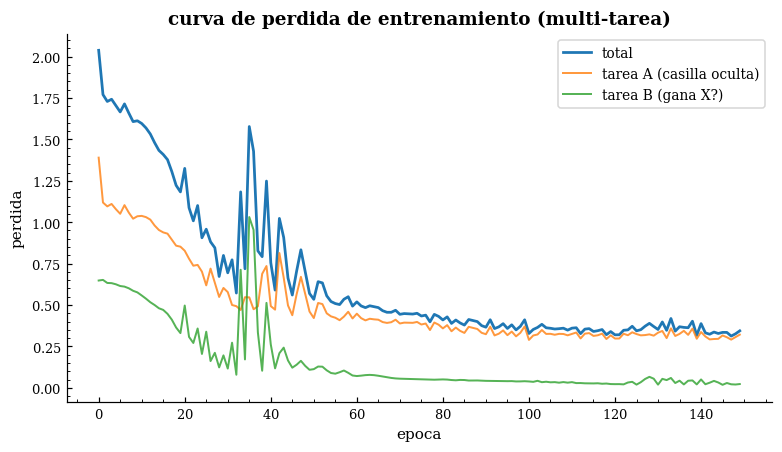

In [32]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(hist["total"], label="total", lw=1.8)
ax.plot(hist["A"], label="tarea A (casilla oculta)", lw=1.3, alpha=0.8)
ax.plot(hist["B"], label="tarea B (gana X?)", lw=1.3, alpha=0.8)
ax.set_xlabel("epoca"); ax.set_ylabel("perdida"); ax.legend()
ax.set_title("curva de perdida de entrenamiento (multi-tarea)")
plt.show()

**Figura 3.** Curva de perdida durante el entrenamiento multi-tarea: la
perdida total (azul) es la suma de la perdida de la tarea de casilla oculta
(naranja) y la de "gana X?" (verde), minimizadas juntas en cada paso con un
unico `backward()`.

## 6. Visualizacion de atencion 

Dos preguntas, dos ejemplos cada una, siempre con la capa 2 (la mas profunda):

- **Casilla oculta.** *Ejemplo 1*: se tapa una casilla que **es parte de la
  linea ganadora real** -- la respuesta correcta se puede leer mirando las
  otras dos casillas de esa linea. Prediccion: la atencion deberia
  concentrarse ahi. *Ejemplo 2*: se tapa una casilla de un tablero **sin
  ninguna linea completa** (empate) -- no hay una linea concreta que mirar, asi
  que se espera una atencion mas repartida.
- **Gana X?** (consulta = token `[CLS]`). Un tablero donde X gana y otro donde
  no, para comparar donde pone el peso el token de clase en cada caso.

Cada heatmap muestra, para la misma consulta, las 4 cabezas por separado --
para ver si aprendieron patrones distintos (una cabeza puede mirar filas, otra
columnas, etc.). Debajo de cada figura se imprime la prediccion real del
modelo: **el heatmap es el "como", el texto es la respuesta.**

In [33]:
def find_first(idx_pool, predicate):
    for idx in idx_pool:
        if predicate(idx):
            return idx
    raise ValueError("no se encontro ningun tablero que cumpla la condicion")

def winning_line_of(board):
    w = winner(tuple(board))
    if w is None:
        return None
    for line in LINES:
        if board[line[0]] == board[line[1]] == board[line[2]] == w:
            return line
    return None

def cell_pred_correcta(idx, mask_pos):
    """True si el modelo YA ENTRENADO predice bien la casilla tapada en idx."""
    ids, _ = build_masked(np.array([idx]), np.array([mask_pos]))
    model.eval()
    with torch.no_grad():
        x_out, _ = model(ids)
        pred = int(model.head_cell(x_out[0, mask_pos]).argmax(-1))
    return pred == boards[idx][mask_pos]

def cls_pred_correcta(idx):
    """True si el modelo YA ENTRENADO predice bien 'gana X?' en idx."""
    ids = build_full(np.array([idx]))
    model.eval()
    with torch.no_grad():
        x_out, _ = model(ids)
        pred = torch.sigmoid(model.head_cls(x_out[0, 9])).item() > 0.5
    return pred == bool(cls_label[idx])

# Elegimos, de forma programatica (primer tablero del set de validacion que
# cumple, sin retoques a mano), un ejemplo de cada categoria donde ADEMAS el
# modelo acierta -- asi la charla se enfoca en el mecanismo de atencion. La
# exactitud global, honesta y sin este filtro, ya se reporto en la Seccion 5.

# ejemplo 1: la casilla tapada pertenece a la linea ganadora real
idx_ej1 = find_first(idx_va, lambda idx: winner(tuple(boards[idx])) is not None
                      and cell_pred_correcta(idx, winning_line_of(boards[idx])[0]))
line_ej1 = winning_line_of(boards[idx_ej1])
mask_ej1 = line_ej1[0]

# ejemplo 2: tablero sin ninguna linea completa (empate) -> no hay linea que mirar
idx_ej2 = find_first(idx_va, lambda idx: winner(tuple(boards[idx])) is None
                      and cell_pred_correcta(idx, 0))
mask_ej2 = 0

print("ejemplo 1 (casilla EN la linea ganadora):")
print_board(boards[idx_ej1], mask_pos=mask_ej1)
print("linea ganadora real: %s = %s (casillas numeradas como en la Seccion 1) | valor tapado real: %s"
      % (line_ej1, LINE_NAMES[line_ej1], CHAR[boards[idx_ej1][mask_ej1]]))

print("ejemplo 2 (tablero sin ninguna linea, empate):")
print_board(boards[idx_ej2], mask_pos=mask_ej2)

ejemplo 1 (casilla EN la linea ganadora):
  ? O O
  X . X
  X X O

linea ganadora real: (0, 1, 2) = fila de arriba (casillas numeradas como en la Seccion 1) | valor tapado real: O
ejemplo 2 (tablero sin ninguna linea, empate):
  ? O X
  X X O
  O X O



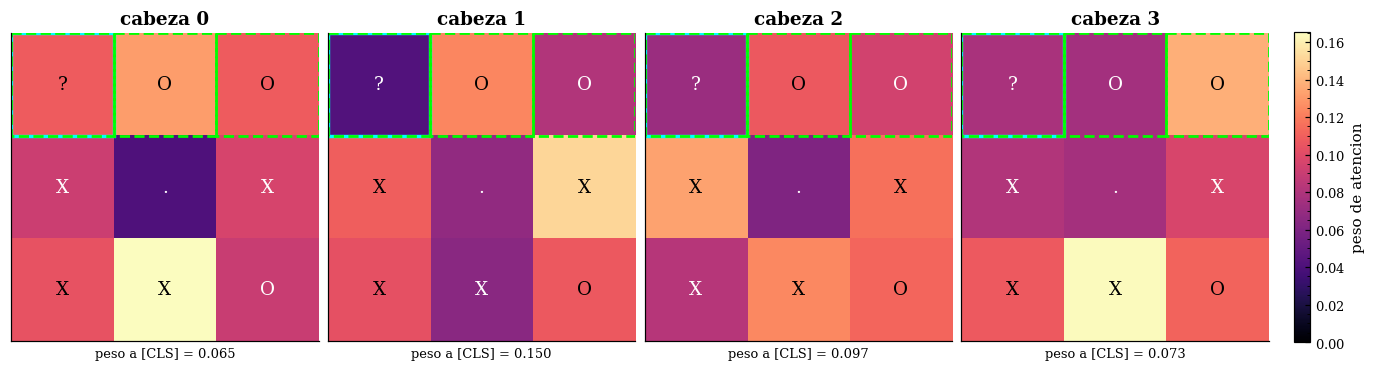

prediccion: O (p(X)=0.002  p(O)=0.603  p(vacio)=0.395)  |  respuesta correcta: O  |  ACIERTA


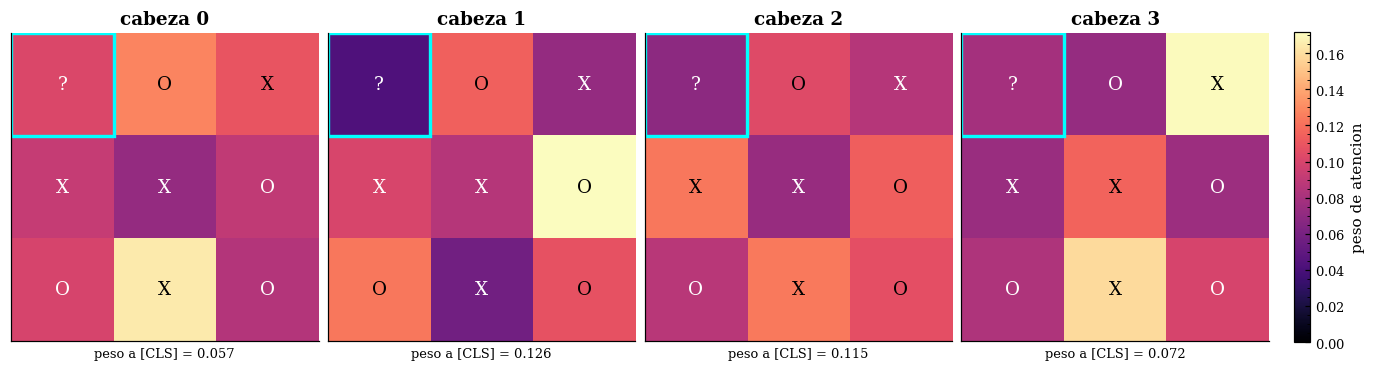

prediccion: X (p(X)=0.811  p(O)=0.002  p(vacio)=0.187)  |  respuesta correcta: X  |  ACIERTA


In [34]:
def plot_masked_attention(idx, mask_pos, highlight_line=None):
    board = boards[idx]
    ids, _ = build_masked(np.array([idx]), np.array([mask_pos]))
    model.eval()
    with torch.no_grad():
        x_out, attn_maps = model(ids)
        logits = model.head_cell(x_out[0, mask_pos])
        probs = torch.softmax(logits, dim=-1)

    A_last = attn_maps[-1][0]           # (n_heads, 10, 10), capa 2
    n_heads = A_last.shape[0]
    row = A_last[:, mask_pos, :]        # (n_heads, 10): fila de la consulta = casilla tapada
    vmax = float(row[:, :9].max())

    fig, axes = plt.subplots(1, n_heads, figsize=(3.1 * n_heads, 3.4), constrained_layout=True)
    im = None
    for h in range(n_heads):
        ax = axes[h]
        w = row[h, :9].numpy().reshape(3, 3)          # las 9 casillas, como tablero 3x3
        im = ax.imshow(w, cmap="magma", vmin=0, vmax=vmax)
        for r in range(3):
            for c in range(3):
                p = 3 * r + c
                lbl = "?" if p == mask_pos else CHAR[board[p]]
                ax.text(c, r, lbl, ha="center", va="center", fontsize=12,
                        color="white" if w[r, c] < 0.6 * vmax else "black")  # texto legible sobre fondo oscuro o claro
        # imshow ubica el centro de la celda p en (columna=p%3, fila=p//3); el
        # rectangulo se dibuja -0.5 corrido para que el borde caiga justo entre celdas
        ax.add_patch(plt.Rectangle((mask_pos % 3 - 0.5, mask_pos // 3 - 0.5), 1, 1,
                                    fill=False, ec="cyan", lw=2.2))       # casilla tapada (la consulta)
        if highlight_line:
            for p in highlight_line:
                ax.add_patch(plt.Rectangle((p % 3 - 0.5, p // 3 - 0.5), 1, 1,
                                            fill=False, ec="lime", lw=1.8, ls="--"))  # linea ganadora real
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("cabeza %d" % h)
        ax.set_xlabel("peso a [CLS] = %.3f" % row[h, 9].item(), fontsize=8.5)
    cb = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02)
    cb.set_label("peso de atencion")
    plt.show()

    real = CHAR[board[mask_pos]]
    pred = CHAR[int(probs.argmax())]
    print("prediccion: %s (p(X)=%.3f  p(O)=%.3f  p(vacio)=%.3f)  |  respuesta correcta: %s  |  %s"
          % (pred, probs[0].item(), probs[1].item(), probs[2].item(), real,
             "ACIERTA" if pred == real else "FALLA"))


plot_masked_attention(idx_ej1, mask_ej1, highlight_line=line_ej1)
plot_masked_attention(idx_ej2, mask_ej2, highlight_line=None)

**Figura 4.** Pesos de atencion de la capa 2 para la consulta "casilla
oculta" (recuadro cian), un panel por cabeza, en un tablero donde esa casilla
pertenece a la linea ganadora real (recuadros verdes). El color de cada celda
es cuanto peso le da esa cabeza a esa casilla al reconstruir el contenido de
la casilla tapada; el numero debajo de cada panel es el peso adicional que se
le da al token `[CLS]` (no graficable en la grilla 3x3).

**Figura 5.** Mismo tipo de figura que la Figura 4, pero en un tablero **sin
ninguna linea completa** (empate): al no haber una linea concreta que
determine la respuesta, se espera -- y se observa -- una atencion mas
repartida entre casillas.

### Ahora la consulta `[CLS]`: "gana X?"

Mismo tipo de figura, pero la fila que se grafica es la del token `[CLS]`
(posicion 9) sobre las 9 casillas -- el tablero completo, sin tapar nada.

tablero donde gana X:
  . . O
  O X O
  X X X

tablero donde X no gana:
  . . O
  . X O
  X X O



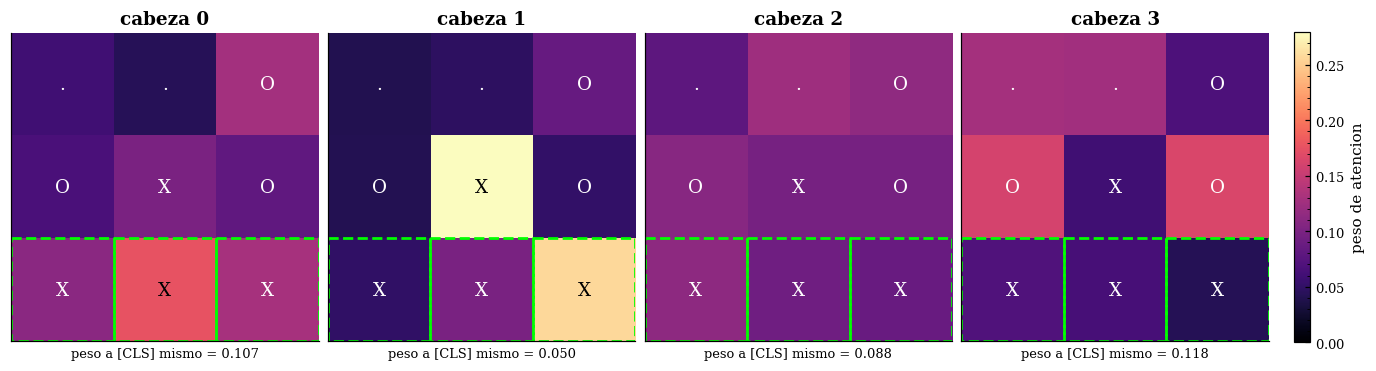

prediccion: gana X = True (p=0.995)  |  respuesta correcta: gana X = True  |  ACIERTA


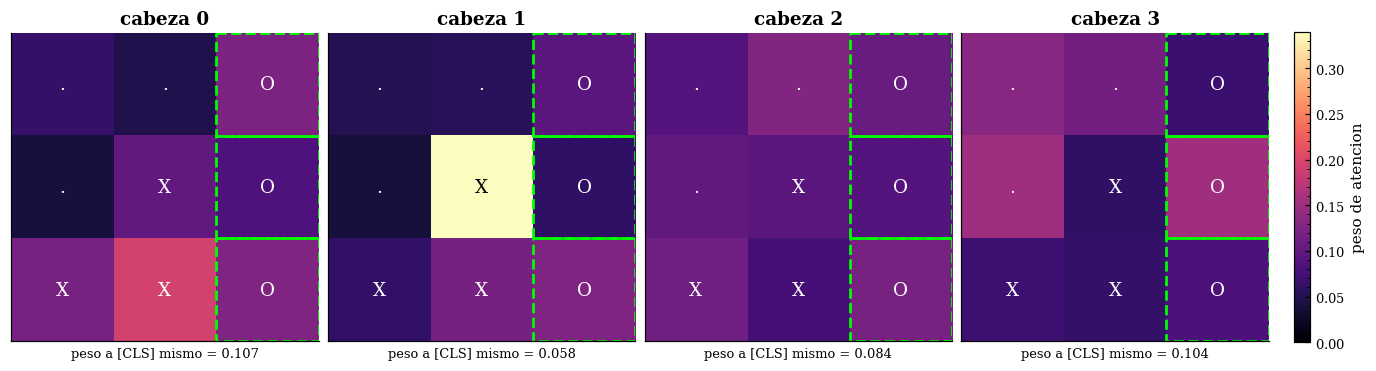

prediccion: gana X = False (p=0.005)  |  respuesta correcta: gana X = False  |  ACIERTA


In [35]:
def plot_cls_attention(idx):
    board = boards[idx]
    ids = build_full(np.array([idx]))
    model.eval()
    with torch.no_grad():
        x_out, attn_maps = model(ids)
        logit = model.head_cls(x_out[0, 9])
        prob = torch.sigmoid(logit).item()

    A_last = attn_maps[-1][0]
    n_heads = A_last.shape[0]
    row = A_last[:, 9, :]               # fila de la consulta = token [CLS]
    vmax = float(row[:, :9].max())
    line = winning_line_of(board)

    fig, axes = plt.subplots(1, n_heads, figsize=(3.1 * n_heads, 3.4), constrained_layout=True)
    im = None
    for h in range(n_heads):
        ax = axes[h]
        w = row[h, :9].numpy().reshape(3, 3)          # las 9 casillas, como tablero 3x3
        im = ax.imshow(w, cmap="magma", vmin=0, vmax=vmax)
        for r in range(3):
            for c in range(3):
                p = 3 * r + c
                ax.text(c, r, CHAR[board[p]], ha="center", va="center", fontsize=12,
                        color="white" if w[r, c] < 0.6 * vmax else "black")  # texto legible sobre fondo oscuro o claro
        if line:
            # -0.5: mismo truco que en plot_masked_attention, para que el borde
            # del rectangulo caiga entre celdas y no cruzando su centro
            for p in line:
                ax.add_patch(plt.Rectangle((p % 3 - 0.5, p // 3 - 0.5), 1, 1,
                                            fill=False, ec="lime", lw=1.8, ls="--"))
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("cabeza %d" % h)
        ax.set_xlabel("peso a [CLS] mismo = %.3f" % row[h, 9].item(), fontsize=8.5)
    cb = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02)
    cb.set_label("peso de atencion")
    plt.show()

    real = bool(cls_label[idx])
    pred = prob > 0.5
    print("prediccion: gana X = %s (p=%.3f)  |  respuesta correcta: gana X = %s  |  %s"
          % (pred, prob, real, "ACIERTA" if pred == real else "FALLA"))


idx_x_gana = find_first(idx_va, lambda idx: winner(tuple(boards[idx])) == X and cls_pred_correcta(idx))
idx_x_pierde = find_first(idx_va, lambda idx: winner(tuple(boards[idx])) != X and cls_pred_correcta(idx))

print("tablero donde gana X:"); print_board(boards[idx_x_gana])
print("tablero donde X no gana:"); print_board(boards[idx_x_pierde])

plot_cls_attention(idx_x_gana)
plot_cls_attention(idx_x_pierde)

**Figura 6.** Pesos de atencion de la capa 2 para la consulta del token
`[CLS]` ("gana X?"), un panel por cabeza, en un tablero donde **X gana**; los
recuadros verdes marcan la linea ganadora real. El numero debajo de cada
panel es el peso que la cabeza se da a si misma (el propio `[CLS]`).

**Figura 7.** Misma figura que la 6, pero en un tablero donde **X no gana**
(en este caso, gana `O`); los recuadros verdes marcan la linea ganadora de
`O`.

## 7. Conexion con el paper, y cierre

| Bloque de la Figura 1 / 2 del paper | Donde esta en este notebook |
|---|---|
| Input Embedding | Seccion 2, `demo_tok_emb` / `TicTacToeEncoder.tok_emb` |
| Positional Encoding | Seccion 2, `demo_pos_emb` / `TicTacToeEncoder.pos_emb` (aprendida, no senoidal, pero el mismo rol) |
| Scaled Dot-Product Attention (Figura 2 izq.) | Seccion 3, calculo manual de `Q, K, V, scores, A, output` |
| Multi-Head Attention (Figura 2 der.) | Seccion 4, `nn.MultiheadAttention` dentro de `EncoderBlock` |
| Add & Norm | Seccion 4, `self.norm1(x + attn_out)` y `self.norm2(x + self.ffn(x))` |
| Feed Forward | Seccion 4, `self.ffn` (Linear-ReLU-Linear) |
| Linear + Softmax final | Seccion 4-5, `head_cell` (3 clases) y `head_cls` (sigmoide) |

**Tres ideas para llevarse:**

1. La atencion son **pesos dinamicos que dependen del input** -- no son un
   parametro fijo como en una capa densa tradicional; se recalculan en cada
   pasada hacia adelante.
2. Permite que **cualquier posicion mire a cualquier otra directamente**, en un
   solo paso, sin la cadena secuencial de una RNN -- por eso hace falta sumar
   la codificacion posicional aparte.
3. El heatmap de atencion es **interpretabilidad**: muestra por donde circulo
   la informacion. La prediccion real es lo que sale **despues** de Add & Norm,
   Feed Forward, y la capa de salida -- el heatmap explica el mecanismo, no
   reemplaza la respuesta.

In [36]:
print("tiempo total del notebook: %.1f s" % (time.time() - T0))

tiempo total del notebook: 12.2 s
